In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../data/saas_churn_cleaned.csv")

#future engineered
df['frustration_index'] = df['support_tickets'] * df['avg_resolution_time']
df['is_high_value'] = (df['monthly_fee'] > df['monthly_fee'].median()).astype(int)

#remove unnecessary columns
cols_to_drop = ['customer_id', 'tenure_bucket', 'customer_segment','has_payment_failure']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    
print("Futures Ready for Training")

Futures Ready for Training


C:\Users\Kwstantinos.Gogg\AppData\Local\Temp\ipykernel_29784\4047119615.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include=['object']).columns:


In [10]:
# split
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# 80 train 20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Train with {len(X_train)} customers. Test with {len(X_test)}.")

Train with 8000 customers. Test with 2000.


In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.00      0.00      0.00       204

    accuracy                           0.90      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.81      0.90      0.85      2000



c:\Users\Kwstantinos.Gogg\OneDrive\Desktop\SaaS Churn Analysis and Prediction\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kwstantinos.Gogg\OneDrive\Desktop\SaaS Churn Analysis and Prediction\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kwstantinos.Gogg\OneDrive\Desktop\SaaS Churn Analysis and Prediction\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

model_v2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_v2.fit(X_res, y_res)

y_pred_v2 = model_v2.predict(X_test_scaled)
print(classification_report(y_test, y_pred_v2))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1796
           1       0.26      0.25      0.26       204

    accuracy                           0.85      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.85      0.85      0.85      2000



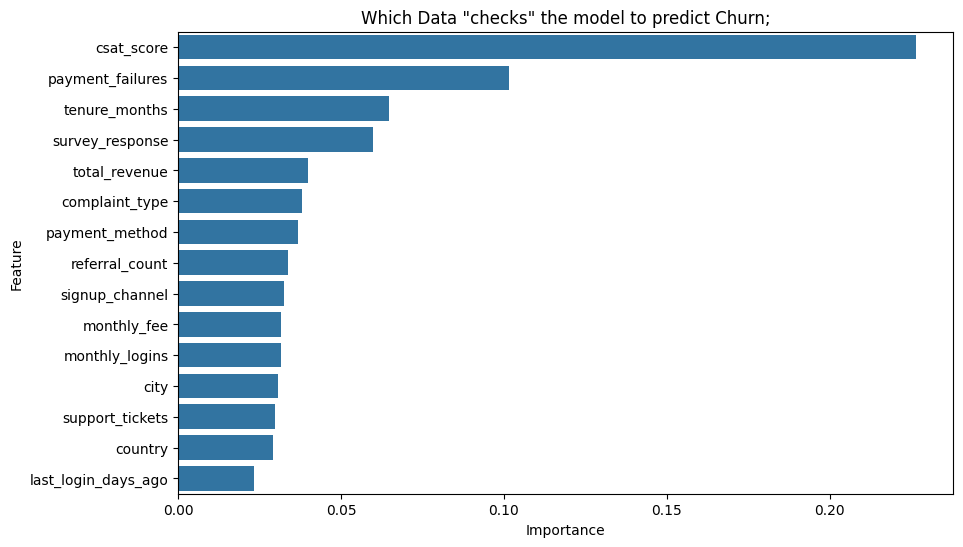

In [ ]:
# 1 Importances
importances = model_v2.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Which Data "checks" the model to predict Churn')
plt.show()

XGBoost & The High-Risk Priority List

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

# 1. Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=6, 
    scale_pos_weight=9, 
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_probs >= 0.3).astype(int)

print("--- XGBoost Model with Custom Threshold (0.3) ---")
print(classification_report(y_test, y_pred_custom))


--- XGBoost Model with Custom Threshold (0.3) ---
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1796
           1       0.24      0.69      0.36       204

    accuracy                           0.75      2000
   macro avg       0.60      0.72      0.60      2000
weighted avg       0.88      0.75      0.79      2000



In [ ]:

test_results = df.loc[X_test.index, ['customer_id','customer_segment']].copy()
test_results['churn_probability'] = y_probs
test_results['actual_churn'] = y_test.values

test_results['churn_probability_pct'] = (
    test_results['churn_probability'] * 100
).round(2).astype(str) + '%'

#filter high risk customers
priority_list = test_results[test_results['churn_probability'] > 0.6] \
    .sort_values(by='churn_probability', ascending=False)
#print session
print("--- TOP 10 HIGH RISK CUSTOMERS TO CALL NOW ---")
print(priority_list[['customer_id','customer_segment','churn_probability_pct']].head(20))

--- TOP 10 HIGH RISK CUSTOMERS TO CALL NOW ---
     customer_id customer_segment churn_probability_pct
8666  CUST_08667       Individual                92.17%
1403  CUST_01404       Individual                91.71%
459   CUST_00460       Individual                90.67%
8677  CUST_08678              SME                89.43%
9263  CUST_09264       Individual                89.37%
156   CUST_00157              SME                89.04%
530   CUST_00531       Individual                88.66%
8961  CUST_08962       Individual                86.44%
8329  CUST_08330       Individual                86.21%
8036  CUST_08037       Individual                85.64%
7016  CUST_07017       Individual                85.34%
5742  CUST_05743              SME                 85.1%
6045  CUST_06046              SME                84.24%
6242  CUST_06243       Individual                84.19%
8847  CUST_08848       Individual                84.16%
9004  CUST_09005       Individual                83.37%
9

In [54]:
# Model predictions
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

results = df.loc[X_test.index, ['customer_id','customer_segment','monthly_fee']].copy()

# churn probability
results['churn_probability'] = y_probs
results['churn_risk_pct'] = (y_probs * 100).round(2)

# Expected Loss = Risk * Revenue
results['expected_loss'] = results['churn_probability'] * results['monthly_fee']

# Sort by business impact
results = results.sort_values(by='expected_loss', ascending=False)

def assign_priority(loss):
    if loss > results['expected_loss'].quantile(0.90):
        return 'CRITICAL (Call Now)'
    elif loss > results['expected_loss'].quantile(0.75):
        return 'HIGH'
    elif loss > results['expected_loss'].quantile(0.50):
        return 'MEDIUM'
    else:
        return 'LOW'

results['priority'] = results['expected_loss'].apply(assign_priority)

print("--- TOP 20 REVENUE PROTECTION LIST ---")
print(results[['customer_id','customer_segment','churn_risk_pct',
               'monthly_fee','expected_loss','priority']].head(20))

--- TOP 20 REVENUE PROTECTION LIST ---
     customer_id customer_segment  churn_risk_pct  monthly_fee  expected_loss  \
3202  CUST_03203       Individual       72.459999          100      72.458184   
6274  CUST_06275              SME       71.239998          100      71.236360   
3299  CUST_03300              SME       67.050003          100      67.046076   
2927  CUST_02928       Individual       65.720001          100      65.716517   
2297  CUST_02298              SME       65.400002          100      65.402681   
2320  CUST_02321              SME       65.290001          100      65.292370   
5302  CUST_05303              SME       59.680000          100      59.677374   
5931  CUST_05932       Enterprise       58.610001          100      58.612806   
9021  CUST_09022       Individual       58.599998          100      58.599800   
9410  CUST_09411              SME       83.190002           70      58.229821   
2636  CUST_02637              SME       79.690002           70      55

In [55]:
# Explainability why customer will churn
top_features = feature_importance_df.head(3)['Feature'].values

results_final = results.join(X_test[top_features])

print(" Actionable List With Context ")
print(results_final[['customer_id', 'priority', 'expected_loss'] + list(top_features)].head(10))

 Actionable List With Context 
     customer_id             priority  expected_loss  csat_score  \
3202  CUST_03203  CRITICAL (Call Now)      72.458184         2.0   
6274  CUST_06275  CRITICAL (Call Now)      71.236360         3.0   
3299  CUST_03300  CRITICAL (Call Now)      67.046076         3.0   
2927  CUST_02928  CRITICAL (Call Now)      65.716517         2.0   
2297  CUST_02298  CRITICAL (Call Now)      65.402681         2.0   
2320  CUST_02321  CRITICAL (Call Now)      65.292370         2.0   
5302  CUST_05303  CRITICAL (Call Now)      59.677374         2.0   
5931  CUST_05932  CRITICAL (Call Now)      58.612806         2.0   
9021  CUST_09022  CRITICAL (Call Now)      58.599800         2.0   
9410  CUST_09411  CRITICAL (Call Now)      58.229821         2.0   

      payment_failures  tenure_months  
3202                 0             13  
6274                 0              3  
3299                 2             25  
2927                 1             51  
2297                